# Tutorial : Split Oversized Traces

## The Problem

Some traces in the dataset are abnormally large.
This happens when the tracing algorithm incorrectly groups **multiple chromatin fibers** into a single trace.
These oversized traces distort downstream distance and contact analyses.

## How `trace_splitter` Works

`trace_splitter` uses a two-step approach:

1. **Measure trace size** — Compute the **radius of gyration (Rg)** of each trace.
   Rg is the average distance of all barcode positions from the trace’s center of mass:

   `Rg = sqrt( mean( |position - center_of_mass|² ) )`

   A larger Rg means the trace is more spread out in 3D space.

2. **Split large traces** — Traces with Rg above a threshold (`mean + std_threshold × std`)
   are split into sub-traces using **K-means clustering** on their 3D coordinates.
   Each resulting cluster gets a new Trace_ID.

## Input

The duplicate-cleaned trace file from Tutorial 4: `merged_traces_cleaned_intensity.ecsv`

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2"
dest_path = f"{data_path}/output"

input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input: {input_trace}")

Input: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv


## Step 1: Run QC Before Splitting

First, let’s run `trace_analyzer` on the input to have a reference for comparison.

In [2]:
!trace_analyzer --input {input_trace}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Number of spots in trace file: 94893
$ Calculating overall barcode detection across 1792 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=0.000, Y=0.000, Z=0.000
$ Calculating barcode stats...
$ Exporting relative ba

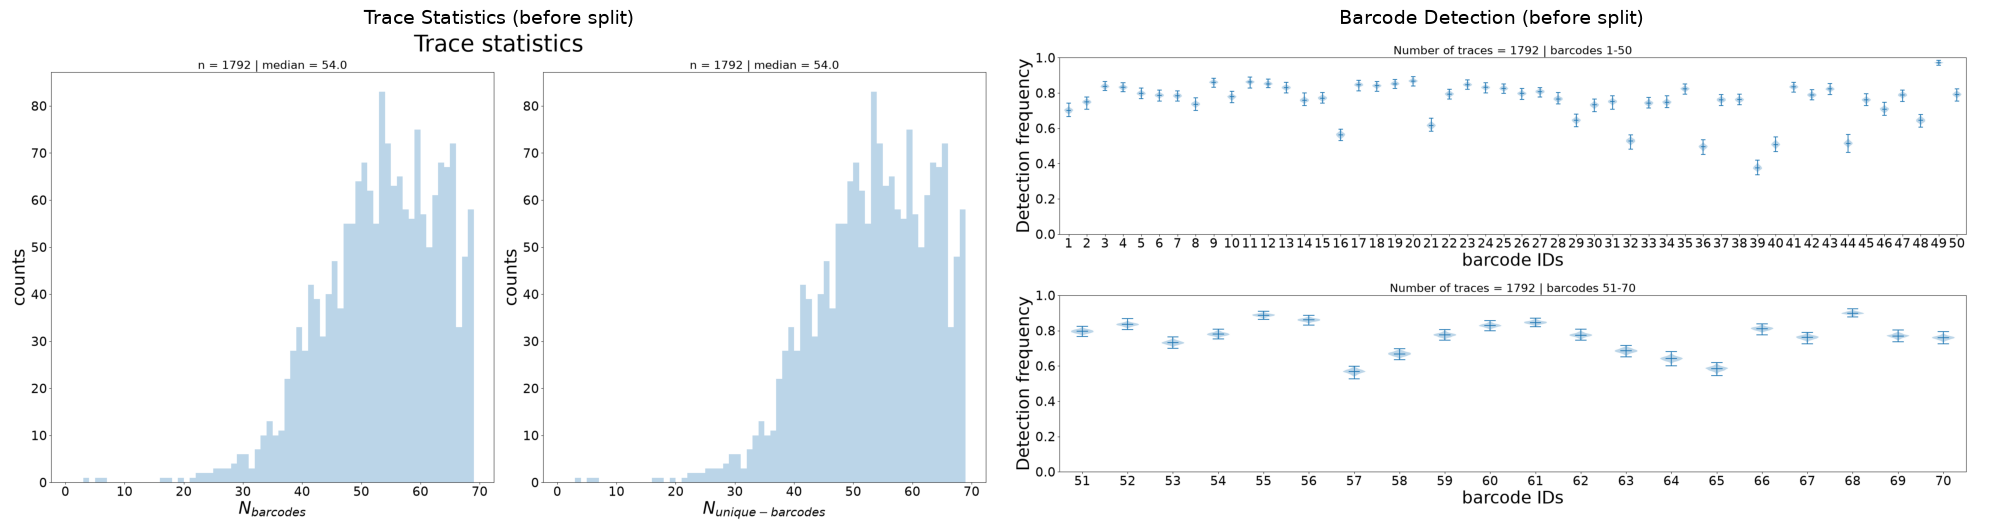

In [3]:
# Display reference plots
before_stats = f"{dest_path}/merged_traces_trace_statistics.png"
before_detect = f"{dest_path}/merged_traces_barcode_detection.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_stats, before_detect],
                         ["Trace Statistics (before split)", "Barcode Detection (before split)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Split Oversized Traces

Run `trace_splitter` with default parameters:
- `--std_threshold 1.0` — split traces with Rg > mean + 1×std
- `--num_clusters 2` — split each oversized trace into 2 sub-traces

In [5]:
!trace_splitter --input {input_trace}

------- Running trace_splitter.py --------
Split chromatin traces using K-means clustering when radius of gyration exceeds a threshold.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
Applying K-means clustering with 2 clusters on traces with Rg > mean + 1.0 * std_dev...
$ Mean Rg: 0.431, Std Rg: 0.110, Threshold: 0.542
$ Number of traces split: 278/1792
$ Saving output table as /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_split.ecsv ...


The output reports:
- The computed **Mean Rg**, **Std Rg**, and **Threshold**
- Each trace that was split, with its Rg value
- Total number of traces split vs total

The output file is saved as `<input>_split.ecsv` alongside the input.

## Step 3: Compare Before vs After

Run `trace_analyzer` on the split output and compare the trace statistics.

In [6]:
split_trace = f"{dest_path}/merged_traces_split.ecsv"
!trace_analyzer --input {split_trace}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_split.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_split.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_split.ecsv
$ Number of spots in trace file: 94893
$ Calculating overall barcode detection across 2070 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_split_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_split_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.000
$ Calculating barcode 

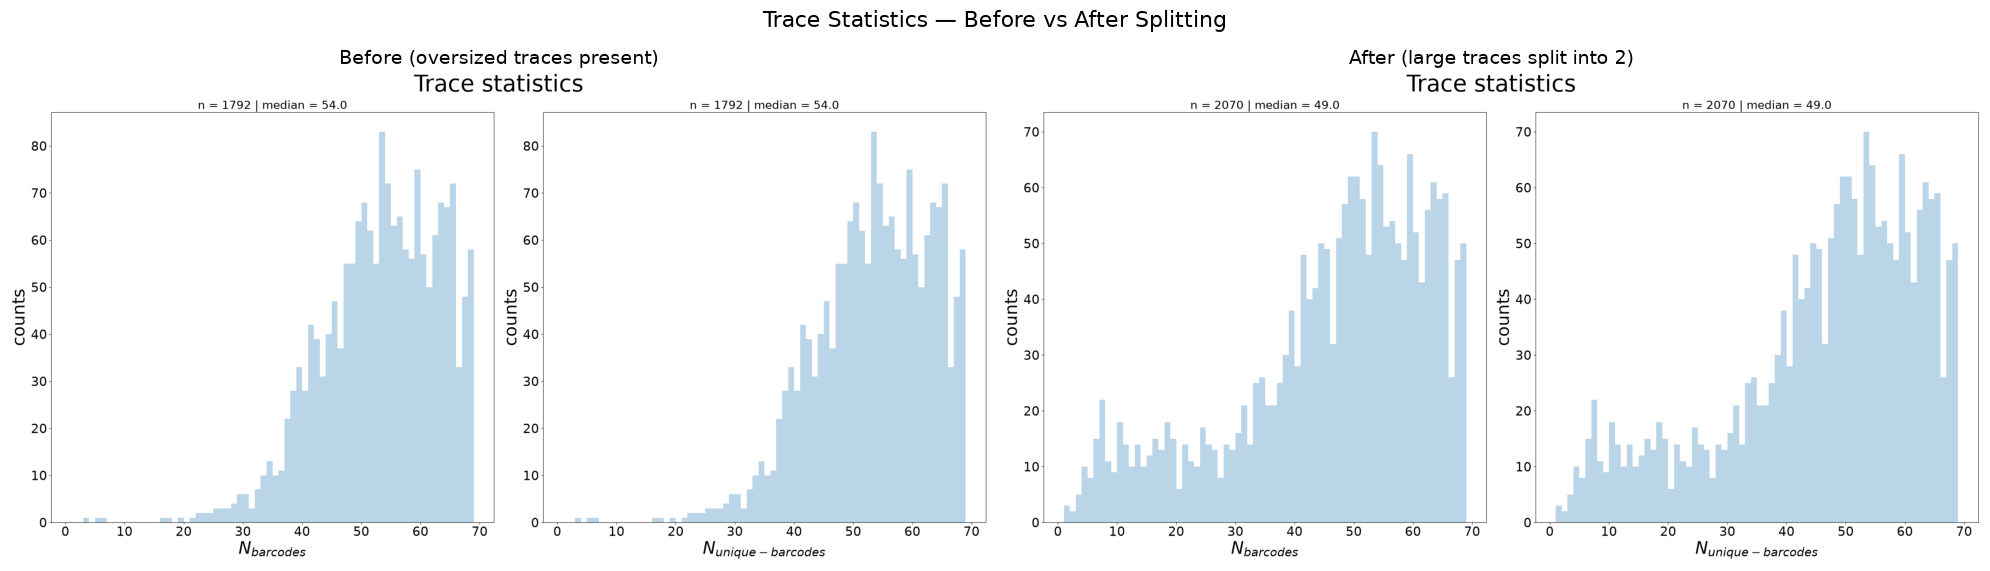

In [7]:
# Compare: Trace Statistics before vs after
after_stats = f"{dest_path}/merged_traces_split_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_stats, after_stats],
                         ["Before (oversized traces present)",
                          "After (large traces split into 2)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Before vs After Splitting", fontsize=16)
plt.tight_layout()
plt.show()

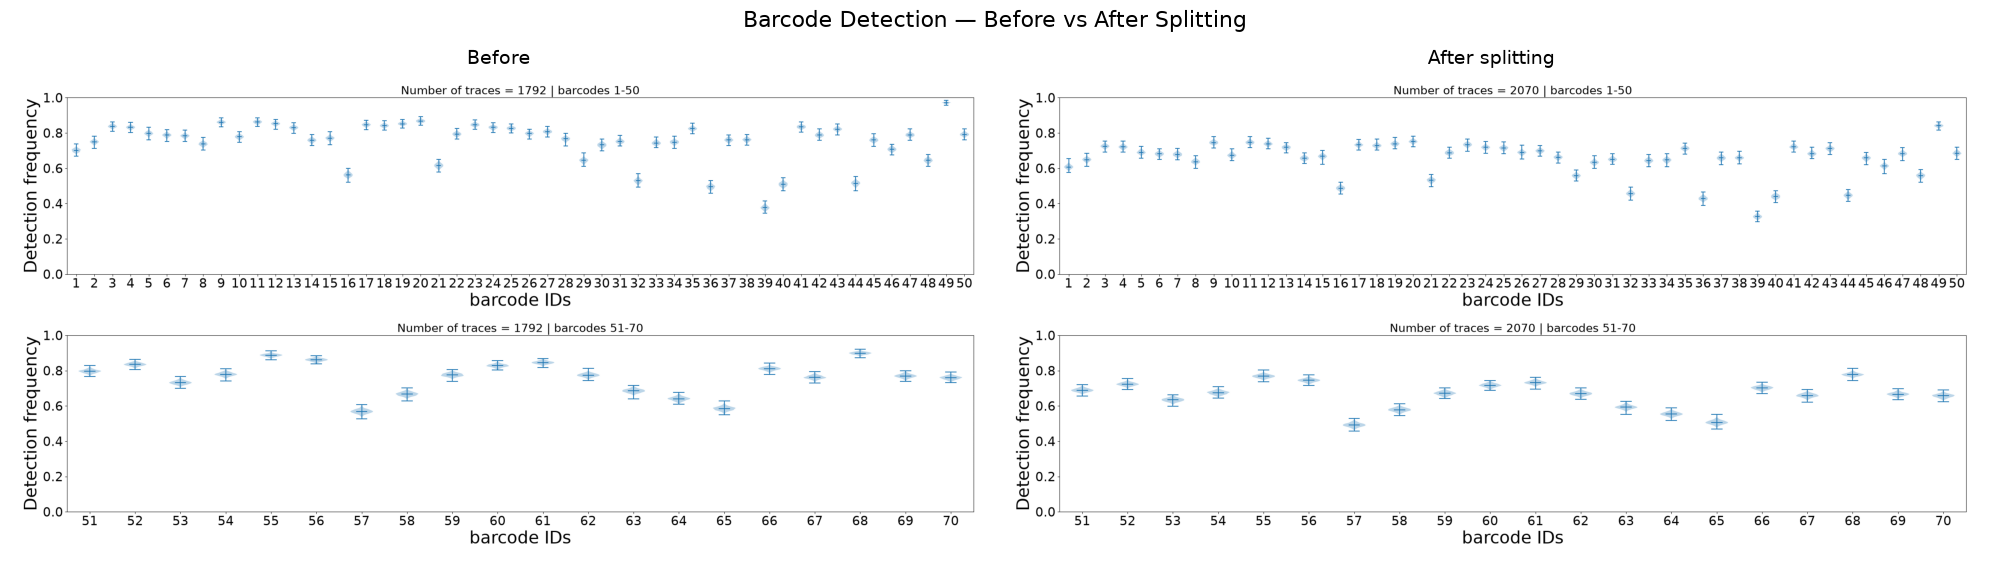

In [6]:
# Compare: Barcode Detection before vs after
after_detect = f"{dest_path}/merged_traces_split_barcode_detection.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_detect, after_detect],
                         ["Before", "After splitting"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Barcode Detection — Before vs After Splitting", fontsize=16)
plt.tight_layout()
plt.show()

**What to check:**
- **N_barcodes** (left panel) shifts left: split traces have fewer barcodes each
- **Total trace count** increases: each split creates one extra trace
- **Barcode detection** may change slightly as trace composition is modified

## About the Parameters

`trace_splitter` accepts two parameters with sensible defaults:

| Parameter | Default | Effect |
|-----------|---------|--------|
| `--std_threshold` | 1.0 | Traces with Rg > mean + N×std are split. Lower = more aggressive. |
| `--num_clusters` | 2 | Number of sub-traces after splitting. |

**The defaults are recommended for most datasets.** Changing them requires a good reason:

- Lowering `--std_threshold` (e.g. 0.5) splits more traces, risking splitting
  legitimate extended conformations
- Raising `--std_threshold` (e.g. 2.0) only splits extreme outliers
- `--num_clusters 3` would only make sense if you suspect
  three distinct fibers were merged into a single trace, which is rare

When in doubt, keep the defaults and inspect the results.

## Summary

| What | How |
|------|-----|
| Detect oversized traces | Radius of gyration (Rg) > mean + std |
| Split them | K-means clustering on 3D coordinates |
| Default behavior | Split into 2, threshold at mean + 1×std |

`trace_splitter` only modifies traces above the Rg threshold.
All other traces pass through unchanged.

**Next:** [Tutorial — Assign Masks & Split by Labels](tutorial_assign_masks_split_labels.ipynb)